<a href="https://colab.research.google.com/github/FX9919/Final-project-used-car-analysis/blob/main/Final_project_used_car_Engineer_%26_Transform_Features_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**import libraries [ 0 ]**


In [258]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

**load clean dataset [ 1 ]**

In [259]:
df = pd.read_csv('cleaned_vehicles.csv') # load the clean dataset

 one hot encoding [ 2 ] categorical columns

هنا عندنا اعمدة:

fuel = نوع الوقود

transmission = نوع القير

one hot encoding convert categorical variables into binary columns to can machin learing model  to understand them
we dont use normal numbers like 1  2 3 because the model will think ther are order between them

In [260]:
df =pd.get_dummies(df,columns=['fuel', 'transmission'])
 # change the columus to numeric 0 and 1 to can model to use them
 #--------------------------------------------------------------------------------------------------------
 # ويعتر خطا مني لو خزنتها بي ارقام لنه كذا راح يفهم المودل انه في ترتيب و اولويات و هذه مو شيء صحيح
 # لنه نوع الوقود او البنزين يختلف ف ياثر على السعر(fuel)  ليه اخترت
 #   الي هو نوع القير طبعا القير العادي ارخص من الاوتاميتك(transmission) واخترت

**ordinal encoding [ 3 ] 1 ordered column**

**the condition show car quality from worst ti best**
here the order id important because condition go from worst too best
the model will understand that better codtion usually mean higher price

In [261]:
condition = {'salvage':1,'fair':2,'good':3,'very good':4,'like new':5}
df['condition'] = df['condition'].map(condition)
#--------------------------------------------------------------------------------------------------------------------------------------
#     هنا فعلا الترتيب مهم  ف ابي اوصل لي المودل اهمية حالة السياره و المودل راح يلاحظ كل ما ارتفعت حالة السياره راح   يزيد السعر

**scaling [ 4 ]**

In [262]:
scaler = StandardScaler()
df[['odometer_scaled','price_scaled']] = scaler.fit_transform(df[['odometer','price']])
#scales numeric features to a similar range
#--------------------------------------------------------------------------------------
# print(df[['odometer_scaled','price_scaled']].mean())  # it make thr mean = 0
# print(df[['odometer_scaled','price_scaled']].std()) # and deviation = 1 this help the model learn better because all features are on the same scale
# print(df[['odometer_scaled','price_scaled']].describe())

domain features [ 5 ]_________________________________________ (featurs created using thing I know about in this topic)

**create car_age instead of using year , it show how old the car to helps predict price better**

In [263]:
df['car_age'] = 2021-df['year']  # create a new feature show the age of the car
print(df['car_age']) # older cars will have lower prices

0       8.0
1       8.0
2       8.0
3       8.0
4       8.0
       ... 
937     5.0
938    10.0
939     6.0
940     3.0
941     8.0
Name: car_age, Length: 942, dtype: float64


create price_per_km to see cost compared to how much the car was used

In [264]:
df['price_per_km'] = df['price']/(df['odometer']+1) # I add +1 to avoid dividing by zero
# show how much we pay for each km
# print(df['price_per_km'])

Interaction Feature [ 6 ]

In [265]:
df['age_mileage'] = df['car_age']*df['odometer']
# combine age and mileage to show their effect together

Log transformation [ 7 ]

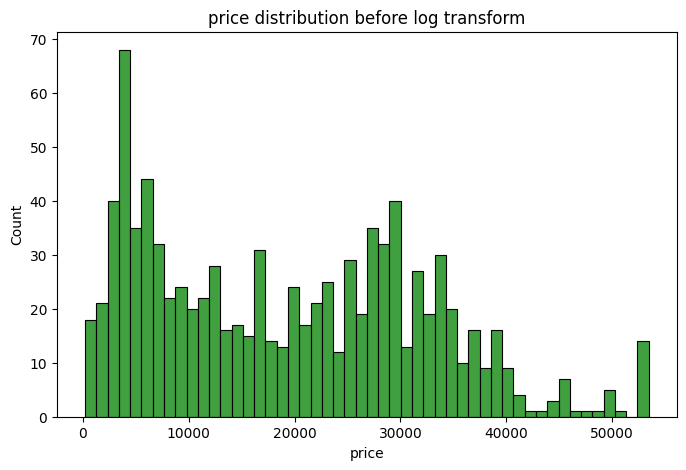

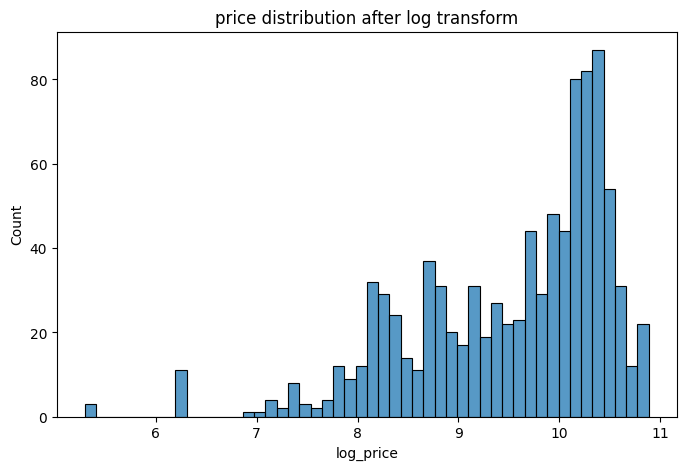

In [266]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'],bins=50 ,color='g')
plt.title('price distribution before log transform')
plt.show() # I notice most cars are lower price and only fwe cars have high prices soo there are skewed

df['log_price']=np.log1p(df['price']) # use log on price to reduce big differences between values
#makes the data more normal and easier to model use them to learn

plt.figure(figsize=(8,5))
sns.histplot(df['log_price'],bins=50)
plt.title('price distribution after log transform')
plt.show() # the data look more normal now     soo it is better for the model

binning [ 8 ] ( فكرته هي تقسيم الارقام لي مجموعات مفهومه )

In [267]:
df['age_group'] = pd.cut(df['car_age'],bins=[0,5,10,20,50],labels=['new','recent','old','very old'])
# group car age into categories for easier analysis

In [268]:
corr_matrix = df.corr(numeric_only=True) # تحسب الارتباطات بين كل عمودين
high_corr_features = corr_matrix[(corr_matrix>0.95)&(corr_matrix<1)] # يختار الاعمده الي مره متشابهين
print(high_corr_features) # find columns that are almost the same
# if two columns are very similar, remove one
df=df.drop(columns=['price_scaled'],errors='ignore') # نحذف واحد منهم عشان المودل ما يتلخبط

                        id  price  year  condition  cylinders  odometer  lat  \
id                     NaN    NaN   NaN        NaN        NaN       NaN  NaN   
price                  NaN    NaN   NaN        NaN        NaN       NaN  NaN   
year                   NaN    NaN   NaN        NaN        NaN       NaN  NaN   
condition              NaN    NaN   NaN        NaN        NaN       NaN  NaN   
cylinders              NaN    NaN   NaN        NaN        NaN       NaN  NaN   
odometer               NaN    NaN   NaN        NaN        NaN       NaN  NaN   
lat                    NaN    NaN   NaN        NaN        NaN       NaN  NaN   
long                   NaN    NaN   NaN        NaN        NaN       NaN  NaN   
fuel_diesel            NaN    NaN   NaN        NaN        NaN       NaN  NaN   
fuel_gas               NaN    NaN   NaN        NaN        NaN       NaN  NaN   
fuel_hybrid            NaN    NaN   NaN        NaN        NaN       NaN  NaN   
fuel_other             NaN    NaN   NaN 